# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import linear_model
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, auc, classification_report
from sklearn.neighbors import KNeighborsClassifier

## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

In [132]:
df_reviews = pd.read_csv("data/reviews_sentiment.csv", sep=";")
df_reviews.head()

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784


In [133]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    object 
 1   Review Text     257 non-null    object 
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    object 
 4   textSentiment   257 non-null    object 
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), object(4)
memory usage: 14.2+ KB


In [134]:
df_reviews["Review Title"].value_counts()

Review Title
Muy buena                          22
Buena                              15
Genial                              7
Muy util                            5
Excelente                           4
                                   ..
Encantada                           1
Muy buena aplicación me encanta     1
Muy buena aplicación                1
Wuau                                1
Sg S5                               1
Name: count, Length: 186, dtype: int64

In [135]:
df_reviews["textSentiment"].value_counts()

textSentiment
positive    211
negative     46
Name: count, dtype: int64

In [136]:
df_reviews["sentimentValue"].value_counts()

sentimentValue
-0.139861    4
 2.066294    4
 2.924393    3
-0.083467    2
 0.789284    2
            ..
 2.098547    1
 2.295086    1
 2.333013    1
 2.814818    1
 3.264579    1
Name: count, Length: 241, dtype: int64

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

In [137]:
df_reviews["Star Rating"].value_counts()

Star Rating
5    88
3    78
1    37
4    30
2    24
Name: count, dtype: int64

In [138]:
df_reviews["Star Rating"].value_counts(normalize=True)

Star Rating
5    0.342412
3    0.303502
1    0.143969
4    0.116732
2    0.093385
Name: proportion, dtype: float64

In [139]:
print(df_reviews["Star Rating"].describe())

count    257.000000
mean       3.420233
std        1.409531
min        1.000000
25%        3.000000
50%        3.000000
75%        5.000000
max        5.000000
Name: Star Rating, dtype: float64


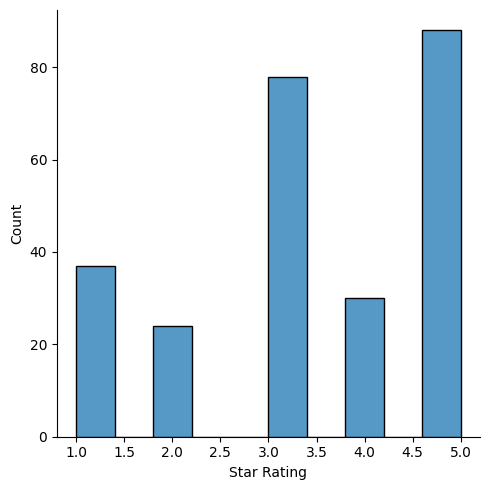

In [140]:
sns.displot(df_reviews["Star Rating"])

In [141]:
df_reviews_corr = df_reviews[["wordcount", "sentimentValue", "Star Rating"]]
df_reviews_corr

,wordcount,sentimentValue,Star Rating
0,23,-0.486389,1
1,20,-0.586187,1
2,4,-0.602240,1
3,17,-0.616271,1
4,6,-0.651784,1
...,...,...,...
252,3,2.814818,5
253,1,2.924393,5
254,1,2.924393,5
255,1,2.924393,5


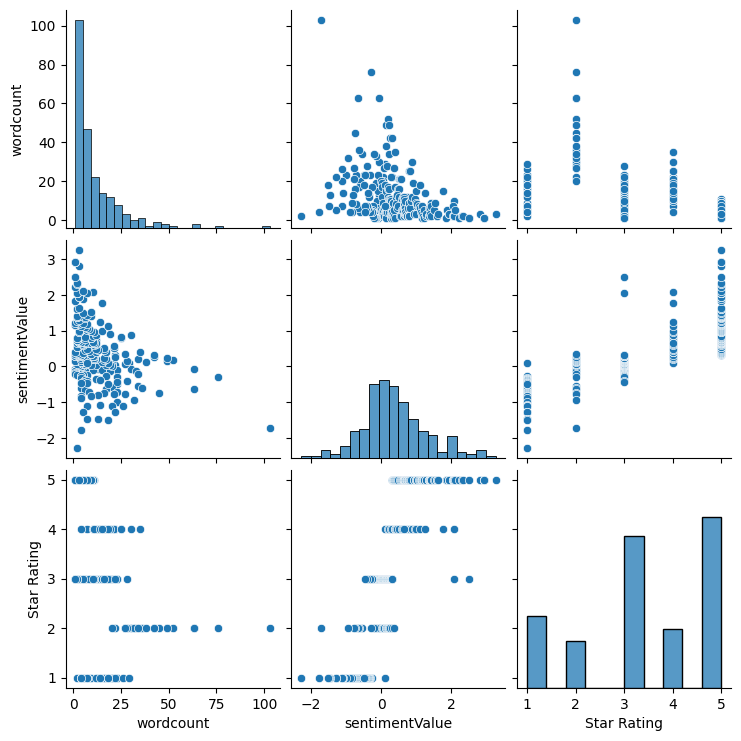

In [142]:
sns.pairplot(df_reviews_corr)

<Axes: >

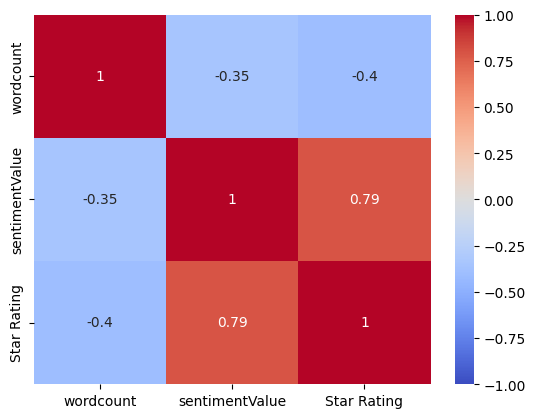

In [143]:
sns.heatmap(df_reviews_corr.corr(), annot=True, vmin=-1, cmap="coolwarm")

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [144]:
X = df_reviews[["wordcount", "sentimentValue"]]
y = df_reviews["Star Rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)



In [145]:
st = MinMaxScaler()
st.fit(X_train)

X_train_st = st.transform(X_train)
X_test_st = st.transform(X_test)

In [146]:
X_train_st

array([[0.60784314, 0.29493351],
       [0.19607843, 0.50314096],
       [0.05882353, 0.39416155],
       [0.07843137, 0.47231225],
       [0.05882353, 0.62268698],
       [0.02941176, 0.30215022],
       [0.07843137, 0.39739518],
       [0.12745098, 0.2153383 ],
       [0.04901961, 0.65668655],
       [0.24509804, 0.21151239],
       [0.04901961, 0.55972724],
       [0.08823529, 0.53591092],
       [0.21568627, 0.323058  ],
       [0.02941176, 0.32671936],
       [0.40196078, 0.45849814],
       [0.47058824, 0.45177168],
       [0.01960784, 0.58232916],
       [0.01960784, 0.58232916],
       [0.10784314, 0.54499328],
       [0.06862745, 0.45386092],
       [0.00980392, 0.52828659],
       [0.18627451, 0.39969233],
       [0.10784314, 0.41803745],
       [0.21568627, 0.35660737],
       [0.01960784, 0.588512  ],
       [0.73529412, 0.35756331],
       [0.07843137, 0.55416951],
       [0.09803922, 0.51745224],
       [0.21568627, 0.39271404],
       [0.02941176, 0.45373837],
       [0.

## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [147]:
knn = KNeighborsClassifier()

knn.fit(X_train_st, y_train)

pred = knn.predict(X_test_st)
print(pred)

[3 5 5 3 5 1 3 3 3 3 3 5 2 2 5 4 5 5 2 3 3 1 5 3 5 5 4 2 1 2 2 3 5 3 1 1 1
 3 5 1 5 3 1 2 5 5 3 3 3 3 5 4]


## Evalúa tu modelo

In [149]:
print("Accuracy:", accuracy_score(y_test, pred))
print("Recall (macro):", recall_score(y_test, pred, average='macro'))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred))

Accuracy: 0.8461538461538461
Recall (macro): 0.801547619047619

Matriz de confusión:
 [[ 7  1  0  0  0]
 [ 0  5  1  0  0]
 [ 1  0 14  0  0]
 [ 0  1  2  3  1]
 [ 0  0  1  0 15]]

Classification report:
               precision    recall  f1-score   support

           1       0.88      0.88      0.88         8
           2       0.71      0.83      0.77         6
           3       0.78      0.93      0.85        15
           4       1.00      0.43      0.60         7
           5       0.94      0.94      0.94        16

    accuracy                           0.85        52
   macro avg       0.86      0.80      0.81        52
weighted avg       0.86      0.85      0.84        52



<Axes: >

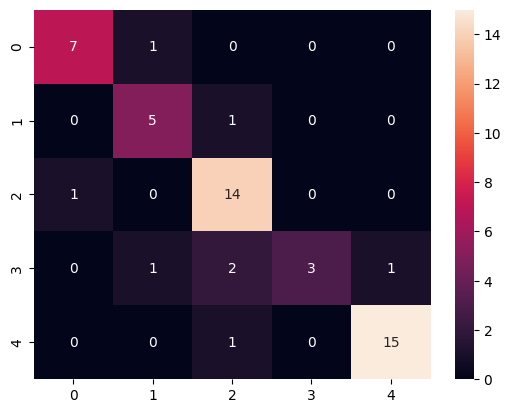

In [150]:
c_matrix = confusion_matrix(y_test, pred)
sns.heatmap(c_matrix, annot=True)

## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? 

3 o 5

Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [120]:
lista_k = np.arange(1, 20, 2)
lista_k

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])

K= 1
[3 5 5 4 5 1 3 3 3 3 3 5 2 2 5 5 5 5 2 4 3 1 5 3 5 5 4 2 1 2 2 3 5 3 1 1 1
 3 4 1 5 3 1 2 5 5 3 3 3 3 5 4]
Accuracy: 0.8653846153846154
--------------------------------------------------
K= 3
[3 5 5 4 5 1 3 3 3 3 3 5 2 2 5 4 5 5 2 3 3 1 5 3 5 5 4 2 1 2 2 3 5 3 1 1 1
 3 5 1 5 3 1 2 5 5 3 3 3 4 5 4]
Accuracy: 0.8461538461538461
--------------------------------------------------
K= 5
[3 5 5 3 5 1 3 3 3 3 3 5 2 2 5 4 5 5 2 3 3 1 5 3 5 5 4 2 1 2 2 3 5 3 1 1 1
 3 5 1 5 3 1 2 5 5 3 3 3 3 5 4]
Accuracy: 0.8461538461538461
--------------------------------------------------
K= 7
[3 5 5 3 5 1 3 3 3 3 3 5 2 2 5 5 5 5 2 3 3 1 5 3 5 5 4 2 1 2 1 3 5 3 1 1 1
 3 5 1 5 3 1 2 5 5 3 3 3 3 5 4]
Accuracy: 0.8076923076923077
--------------------------------------------------
K= 9
[3 5 5 3 5 1 3 3 3 3 3 5 2 2 5 5 5 5 2 3 3 1 5 3 5 5 5 2 1 2 1 3 5 3 1 1 1
 3 5 1 5 3 1 2 5 5 3 3 3 3 5 4]
Accuracy: 0.7884615384615384
--------------------------------------------------
K= 11
[3 5 5 3 5 1 3 3 3 3 3 5 4 2 5 5 5

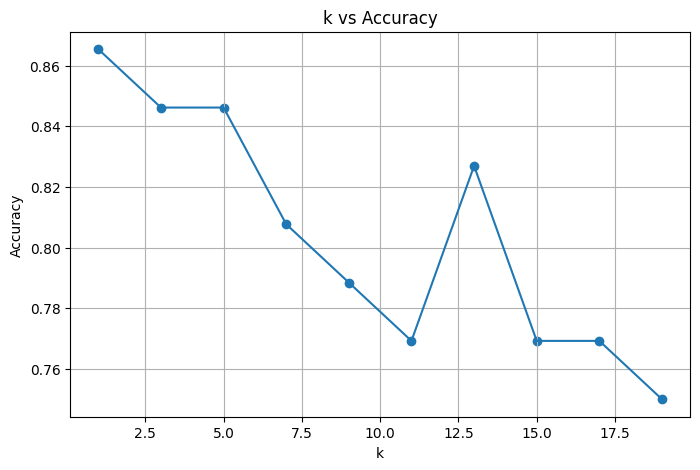

In [121]:
lista_accuracy = []

for k in lista_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_st,y_train)
    pred_knn = knn.predict(X_test_st)
    acu = accuracy_score(y_test, pred_knn)
    lista_accuracy.append(acu)
    print('K=',k)
    print(knn.predict(X_test_st))
    print("Accuracy:", accuracy_score(y_test, pred_knn))
    print('-'*50)

plt.figure(figsize=(8, 5))
plt.scatter(lista_k, lista_accuracy)
plt.plot(lista_k, lista_accuracy)  # opcional, para ver la tendencia
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k vs Accuracy")
plt.grid(True)
plt.show()

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [151]:
# Predicción sin normalizar datos
pred = knn.predict([[5, 1]])
knn.fit(X_train_st, y_train)
print(pred)

[2]


In [152]:
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_st, y_train)

# Predicción normalizando datos
datos_st = st.transform([[5, 1]])
pred_st = knn_final.predict(datos_st)
print(pred_st)

[5]


c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [153]:
pred_st = knn.predict_proba(datos_st)
print(pred_st)

[[0. 0. 0. 0. 1.]]


# Mejor valor de K y grafica con GridSearch

In [158]:
knn_gs = KNeighborsClassifier()

parametros = {'n_neighbors': np.arange(1, 20, 2)}

modelo_gs = GridSearchCV(knn_gs, parametros, cv=10, scoring='accuracy', verbose=3)

modelo_gs.fit(X_train_st, y_train)

print("Mejor K:", modelo_gs.best_params_)
print("Mejor accuracy:", modelo_gs.best_score_)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV 1/10] END ....................n_neighbors=1;, score=0.857 total time=   0.0s
[CV 2/10] END ....................n_neighbors=1;, score=0.857 total time=   0.0s
[CV 3/10] END ....................n_neighbors=1;, score=0.810 total time=   0.0s
[CV 4/10] END ....................n_neighbors=1;, score=0.905 total time=   0.0s
[CV 5/10] END ....................n_neighbors=1;, score=0.905 total time=   0.0s
[CV 6/10] END ....................n_neighbors=1;, score=0.800 total time=   0.0s
[CV 7/10] END ....................n_neighbors=1;, score=0.750 total time=   0.0s
[CV 8/10] END ....................n_neighbors=1;, score=1.000 total time=   0.0s
[CV 9/10] END ....................n_neighbors=1;, score=0.800 total time=   0.0s
[CV 10/10] END ...................n_neighbors=1;, score=0.900 total time=   0.0s
[CV 1/10] END ....................n_neighbors=3;, score=0.857 total time=   0.0s
[CV 2/10] END ....................n_neighbors=

In [159]:
print(modelo_gs.best_estimator_)
print(modelo_gs.best_params_)
print(modelo_gs.best_score_)

KNeighborsClassifier(n_neighbors=np.int64(9))
{'n_neighbors': np.int64(9)}
0.8628571428571428


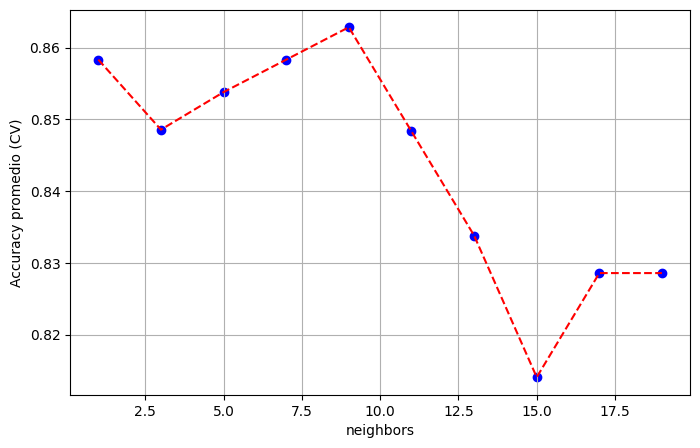

In [160]:
k_values = np.arange(1, 20, 2)

mean_accuracy = modelo_gs.cv_results_['mean_test_score']

plt.figure(figsize=(8, 5))
plt.scatter(k_values, mean_accuracy, color='blue')
plt.plot(k_values, mean_accuracy, color='red', linestyle='--')
plt.xlabel("neighbors")
plt.ylabel("Accuracy promedio (CV)")
plt.grid(True)
plt.show()

In [161]:
modelo_final = modelo_gs.best_estimator_
modelo_final.fit(X_train_st, y_train)

,n_neighbors,np.int64(9)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [163]:
knn_gs = KNeighborsClassifier(n_neighbors=9)

knn_gs.fit(X_train_st, y_train)

datos_st_02 = st.transform([[5, 1]])

pred_st_02 = knn_gs.predict(datos_st)
print(pred_st_02)


[5]


c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
